# Lab 060 · A model comparison a skeptic can rerun

[Lesson](../lessons/0060-broad-model-comparison.html) · [Reference](../reference/0060-broad-model-comparison.html) · [Measured evidence](_verify_l060_v2_results.json) · [Source inventory](_sources_l060_v2.json) · [Reproduction](l060-reproduction.md)

**Outcome:** five live audit/selection functions, a fresh five-arm smoke, a fully reconstructed 210-record author panel, and a defensible EXIT report. This is a protocol checkpoint: reused neural implementations remain visible and tree libraries are peripheral baselines. CPU-only core; no pretrained checkpoint. The full eleven-dataset run is author-reference evidence, not a result you have already obtained. Live Colab UI remains unverified. Read, predict, implement, audit, then explain.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## The checkpoint is a defensible comparison

A future relational model must beat a credible single-table procedure. That means more than placing five model names in a table: the competitor includes the feature representation, optimizer, search, validation rule and resource budget. Your outcome here is a report whose selected models, predictions, uncertainty and recommendation can all be reconstructed. A failed neural improvement is a valid outcome.

**Retrieve first, without notes.** From Lesson 058, why can a carefully chosen collection of datasets still favor a particular family? From Lesson 059, which labels may select a candidate, and which labels may estimate its performance? From Lesson 054, does TabM train on the loss of the average prediction or the average of member losses? Write your answers before reading the code.

This is an evaluation checkpoint, introducing no new model. We reuse the numerical MLP, RealMLP-TD-S and corrected TabM-mini taught earlier, with XGBoost and CatBoost as established comparator libraries. The new implementation skill is the **evidence chain**: validate the partitions, freeze a choice, reconstruct its metric, check the declared panel, and compute paired effects. Five live notebook functions implement these operations; a small fresh five-arm training run and the full saved-panel audit both use them.

The earlier 210-record result remains available as historical evidence. It used `relkit/tabm.py`, whose mini architecture retained extra adapters and used incorrect fan-in initialization. The corrected measurement uses `relkit/tabm_v2.py` and a separate `checkpoint_l060_v2.py`; its source hashes and all 210 newly fitted results are in the [v2 evidence](_verify_l060_v2_results.json). Historical numbers must never be relabeled as corrected-model evidence.

### Turn a model comparison into an executable argument

The checkpoint asks you to connect four things: a deployment question, a training procedure, saved predictions and a conclusion. If any link is missing, the result becomes difficult to audit. A score table without row identities cannot prove pairing; a recipe without predictions cannot reconstruct the metric; a conclusion without a target population can overgeneralize the evidence.

Begin with an explicit claim template: “Under these fixed splits and resource limits, procedure A had this measured advantage over procedure B, with this variation across repetitions.” Fill it from artifacts after the run. This keeps the prose attached to what was actually measured.

Random and temporal splits form separate panels because they ask different questions. The same dataset appearing in both panels is not two independent datasets. Likewise, three seeds on fixed rows improve your view of algorithmic variability without tripling the number of independent tasks.

The checkpoint deliberately reuses strong tree and neural recipes. Its purpose is to compare credible procedures, not to make a new architecture look good against an undertrained baseline. Family-specific preprocessing and optimization are acceptable when their information access and resource allocation are declared.

### Decide what failure means before encountering it

A timeout, unsupported feature type, nonfinite prediction and ordinary poor score are different outcomes. Preserve their status and cost. Silently dropping unsuccessful tasks can make a procedure look stronger by changing its denominator. A deployment decision may care deeply about coverage and reliability even when average loss on successful tasks is excellent.

## Four papers ask different comparison questions

Read [TabArena v1 §§2–3 and Appendices A–D](https://arxiv.org/html/2506.16791v1), then [TabReD v4 §5.4 and Appendix C](https://arxiv.org/html/2406.19380v4). These are complementary protocol references. The first focuses on curated IID tasks and peak attainable procedures; the second asks how evaluation changes when future rows replace shuffled rows. Their rankings cannot be stitched into one leaderboard.

| Source and exact scope | Load-bearing contribution | What this checkpoint does |
|---|---|---|
| TabArena v1 §§2.1–2.3, A.4–A.5, C.1–C.2 | 51 curated tasks; inner eight-fold ensembles, one default plus 200 sampled configurations; repeated outer evaluation; explicit preprocessing and prediction artifacts | Imports the idea of an explicit procedure and auditable artifacts; uses a small fixed holdout, two candidates, no outer CV or post-hoc ensemble |
| TabReD v4 §5.4 and Appendix C | Three paired random/temporal splits and 15 initializations study changes in relative performance | Uses three released datasets, one split pair, three seeds and reduced row counts; estimates a conditional regime contrast |
| [TabM v3 §§3.3–3.4, D.2–D.3](https://arxiv.org/html/2410.24210v3) | A minimal first-input adapter creates member diversity; shared backbone and separate heads; memberwise training, prediction averaging | Corrected mini architecture, eight members, shared training batches, no nonlinear feature embeddings, smaller training budget |
| [RealMLP v2 §3, A.2, C.6](https://arxiv.org/html/2407.04491v2) | A complete tuned-default recipe, simplified TD-S variant, validation checkpoint selection and explicit aggregate uncertainty | Reduced TD-S at width 64 and 24 epochs; log-loss validation instead of the paper's main accuracy selection |

TabArena's main binary metric is AUROC, while this checkpoint uses log loss. Its default RealMLP configuration disables label smoothing for its metric; ours retains the simplified original classification recipe's smoothing. TabM's paper also uses a special standard-deviation-based ranking rule, whereas ours uses ordinary average-tie ranks. Matching model names therefore does not imply matching procedures. The [claim/source inventory](_sources_l060_v2.json) and [reproduction contract](l060-reproduction.md) pin the exact sources, implementation dependencies and remaining work.

## Freeze the experiment before fitting

Bring the seven decisions from Lesson 059: **metric, candidate procedures, split identity, tuning budget, selection rule, freeze point, postponed adjustment**. If you have its `exit.json`, compare that ledger to this protocol. A disagreement is a declared change before a fresh run, not permission to rewrite a decision after seeing the test result. The author correction was motivated by a code defect already discovered; it is a new measured operator, not independent confirmation of a hypothesis invented from its new scores.

Eight familiar public datasets—diabetes, blood transfusion, kc1, phoneme, German credit, churn, bank marketing and adult income—form the continuity panel. They are real data, but this convenient course roster has not passed TabArena's full curation. The released Ecom Offers, Homesite Insurance and Sberbank Housing tasks add random and temporal panels. There are **14 dataset/regime cells, 11 underlying datasets and 210 selected fits**: 14 × 5 methods × 3 seeds. The two regimes of one TabReD dataset are related observations.

| Decision | Frozen local value | Why it matters |
|---|---|---|
| Public rows | At most 900, sampled without labels by RNG 60 | Small-data comparison; different from full datasets |
| Public partitions | 60/20/20; first split RNG 60, second RNG 61; both stratified | Explicit split identity, identical rows across arms |
| TabReD rows | Released `random-0` and `sliding-window-0`; caps 540/180/180 | Matches regime pair at one window, not full paper scope |
| TabReD cap draws | RNG 550/551/552 for train/validation/test; sampled IDs sorted | Label-blind sampling reproducible from released pools |
| Model seeds | 0, 1, 2 crossed with all arms | Same seed keys permit pairing, not identical random draws across libraries |
| Candidate budget | Two configurations per arm; every candidate fitted | Search cost includes both the winner and loser |
| Selection | Minimum validation loss, first candidate on ties | Test labels never choose a candidate |
| Neural checkpoint | Lowest validation error among 24 epochs, last epoch on ties | Epoch selection is additional adaptation |
| Failure | Stop with an incomplete artifact; no rank summary until complete | A failed task cannot silently disappear from the denominator |

No arm is refitted on train plus validation after selection. The selected fitted object is evaluated as it stands. Changing this would create another procedure with a different training size. Equal candidate counts do not equalize search power: neural methods also compare epochs, and one tree configuration can cost more than another. Equal wall-clock limits or published defaults would each answer a different practical question.

### Row identity is the spine of the comparison

Let I_train, I_valid and I_test be sets of stable row IDs. Each must be nonempty, contain no duplicate ID and be disjoint from the others. These are structural assertions you can test before fitting. They do not prove that features are historically legal or that entities are independent, but they catch a large class of accidental overlap and alignment errors.

Store these IDs with the dataset version and target definition. A positional index generated after sorting is not necessarily the same identity used before sorting. When predictions are saved, include the row IDs so metrics can be reconstructed in the original order or after an explicit join.

Preprocessing must be fitted on the training rows. Validation and test then pass through that frozen state. For a temporal panel, any label-based retrieval or feature aggregation must additionally respect the time at which information became available. The split validator is one gate, not the entire leakage audit.

Candidate budgets should be declared before fitting. Equal candidate counts, equal wall-clock limits and published defaults are distinct comparison designs. Record the one you use and the realized resources. A method receiving a larger search should not be described as winning solely because of its architecture.

Preserve each baseline's defining recipe. RealMLP's scaling and optimizer groups, TabM's member objective and probability aggregation, and tree early-stopping settings all affect the fitted procedure. Reusing a name while replacing its recipe with a generic loop weakens the comparison.

## Preserve each baseline's important recipe

The common encoder fits numeric medians and categorical one-hot columns on training rows only. Validation and test transform through that fixed state. Unseen categories become an all-zero one-hot block. For example, training cities `{A,B}` become `[1,0]` and `[0,1]`; future city `C` becomes `[0,0]`, not a third column learned from test data. Numeric missingness receives the training median; a column entirely missing in training is filled with zero because its median is undefined. The categorical path casts values to strings, so a missing categorical value can itself be a category if observed in training.

Common one-hot input is a **controlled representation restriction**. It suppresses CatBoost's native categorical machinery, so this is not a test of the strongest available mixed-type CatBoost pipeline. For TabReD we retain numeric and binary columns and count omitted categorical columns. Data and feature hashes document the actual inputs. A clean splitter cannot undo a feature that already contains future information: availability of source aggregates and label arrival times remains an independent audit question.

| Arm | Candidate difference | Fit and inference path |
|---|---|---|
| XGBoost | Depth 3 or 6 | 100 histogram boosting rounds, learning rate .05, row/column subsampling .8 |
| CatBoost | Depth 4 or 6 | 100 iterations at .05, one thread, common one-hot input, no validation early stopping |
| MLP | AdamW learning rate .001 or .003 | Training-derived standardization; three width-64 ReLU/dropout blocks, dropout .1, weight decay 1e−4 |
| Reduced RealMLP-TD-S | Base learning rate multiplier 1 or .5 | Robust scaling and smooth clipping; trainable feature scales, NTP layers, SELU/Mish, Adam (.9,.95), coslog4 schedule and parameter groups; classification smoothing .1 |
| Corrected TabM-mini | AdamW learning rate .001 or .003 | Standardization, first-input adapter only, three shared width-64 blocks, shared backbone biases, eight distinct heads, dropout .1, weight decay 1e−4 |

The neural models always complete 24 epochs; validation selects the returned state. The RealMLP schedule is compressed into that duration, so “24 out of 256 epochs” would be misleading: we traverse a complete shortened schedule. The corrected TabM-mini removes the extra first-output adapter and member backbone biases and initializes stored `[input,output]` weights by their actual input dimension. The existing Lesson 054 copied-weight source check validates the numeric architecture; it does not certify this benchmark recipe.

For TabM classification, member logits have shape `[batch,8,2]`. Training averages eight cross-entropies; inference softmaxes each member then averages probabilities. With true class 1 and member probabilities .9 and .1, mean member loss is `(-ln .9 - ln .1)/2 ≈ 1.204`, while loss of the averaged probability is `-ln .5 ≈ .693`. The second objective permits compensation between members; the measured operator uses the first. Neither eight members nor three model seeds create extra independent datasets.

![Synthetic worked protocol: validation [.43,.39] selects candidate 1. Only then may test labels enter the evaluator. The selected neural epoch and the candidate index are different choices.](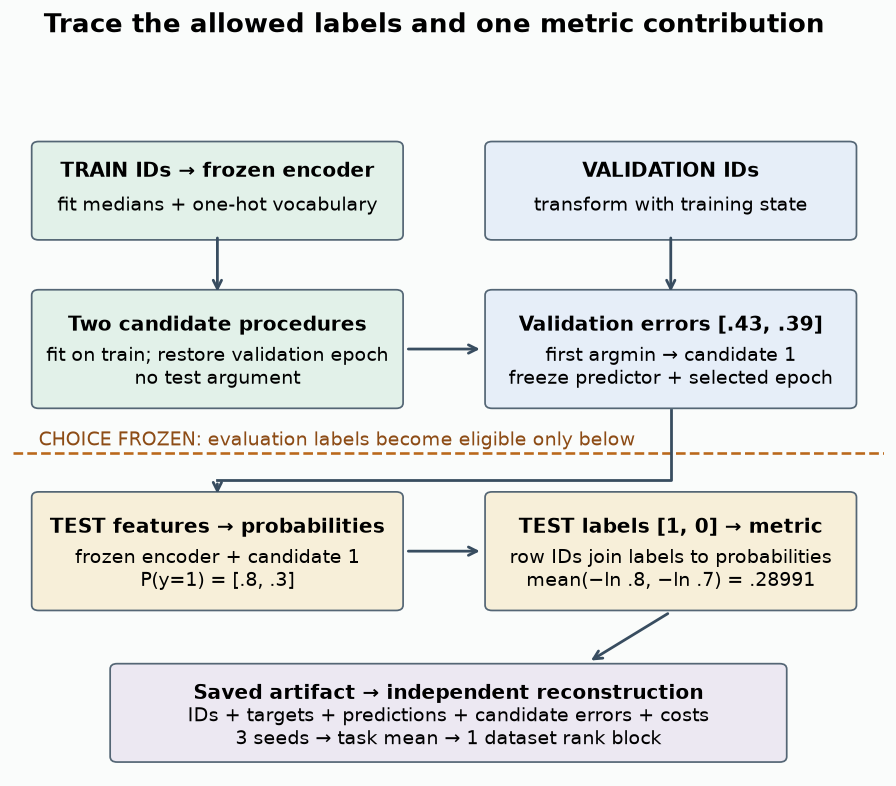)

Synthetic worked protocol: validation [.43,.39] selects candidate 1. Only then may test labels enter the evaluator. The selected neural epoch and the candidate index are different choices. [Open full-size figure](figures/l060/protocol-v2.png).

## Test labels enter once the choice is frozen

Follow the diagram's boundary. The fitter receives training arrays and validation arrays, returns one frozen predictor plus its validation error and selected epoch, and has no test argument. The selector sees only the two validation errors. Only then does the selected predictor receive test features and the metric function receive test labels. A notebook CHECK changes saved targets and confirms that candidate selection is unchanged while metric reconstruction detects the changed evidence.

Suppose candidate validation errors are `[.43,.39]`, but their unknown test errors would be `[.37,.46]`. The valid choice is candidate 1, with reported test error .46. Reporting .37 would select on the evaluation set. If the deployment decision itself chooses between all five families after this report, its final chosen-family estimate may also be optimistic: a new untouched evaluation or nested selection is needed for that extra adaptive step. The saved five-arm table still validly describes its declared fixed procedures.

Row identity is equally necessary. A probability vector has no meaning until linked to target rows and class order. Each v2 record contains test IDs in order, targets, `P(y=1)` or scalar regression predictions, class schema, all candidate validation losses, each candidate's selected epoch and the winning index. The audit demands that every arm/seed of a task uses the same target sequence and the exact declared test-ID order. This catches accidental shuffling; it cannot prove that the raw dataset's semantic feature construction was leak-free.

### Save the choice before saving its evaluation

Suppose validation chooses candidate 2 from a list of five. Save that index, its hyperparameters and its checkpoint identity before calculating the final test metric. This makes the causal order inspectable: validation selected; test evaluated. A later analysis can reconstruct the decision without relying on a narrative about what the author intended.

For classification, store class order with probability columns. For regression, store the output units and any inverse target transform. A correct model can appear wrong if predictions and labels are misaligned, and an incorrect metric implementation can produce a plausible-looking number.

Reconstruct the score from saved predictions using a separate evaluator. This checks the artifact chain and allows future summaries without refitting. It does not create a second independent experiment. Reanalysis and new measurements must be labeled separately.

If you inspect test failures and then change the model, the change is a new hypothesis informed by that test. Keep the original result and obtain fresh evaluation evidence for the revision. The practical goal is not to avoid learning from mistakes; it is to stop using the same evidence both to invent and confirm the fix.

## Derive the reported errors

For binary labels `y_i ∈ {0,1}` and probabilities `p_i=P(y_i=1)`, the probability assigned to the observed label is `p_i` when `y_i=1` and `1−p_i` otherwise. Taking the negative log turns confident mistakes into large penalties; averaging gives

`log_loss = −(1/n) Σ_i [y_i ln(p_i) + (1−y_i) ln(1−p_i)]`.

For labels `[1,0]` and probabilities `[.8,.3]`, the contributions are `.22314` and `.35667`, giving `.28991`. Threshold accuracy would discard how confident those predictions were. The implementation checks finite aligned one-dimensional arrays, binary labels and probabilities in `[0,1]`, then clips to float64 machine epsilon and its complement to make endpoint logs finite. A malformed probability of 1.1 is rejected before clipping; clipping is not a license to repair invalid outputs silently.

For regression, square each residual in the released target's units, average, and take the square root: `RMSE = sqrt(mean((y−ŷ)²))`. Targets `[1,5]` and predictions `[4,1]` give squared residuals `[9,16]` and RMSE `sqrt(12.5) ≈ 3.5355`. For the released Sberbank data the target is `log(price_doc/full_sq)`: RMSE is in those logarithmic units, not currency and not raw sale-price RMSE. Its train and validation time ranges meet on a tied timestamp in split 0. The artifact accurately records non-strict ordering; a strictly later label-availability claim would require more evidence.

Do not average raw log loss and RMSE across tasks: the units differ, and a change of target units could determine the result. Compare raw effects within each task, then use dimensionless ranks to summarize a declared task collection.

## Read the result at three resolutions

**Predict first:** if A's losses across two seeds are `[0,1]` and B's are `[.4,.4]`, which method should rank first after seed averaging? A wins one seed emphatically; B has the better average loss, .4 versus .5. If you rank separately per seed and average ranks, both receive 1.5. That is a different estimand: mean seedwise ordering rather than ordering of estimated mean loss. Move the slider and find the tie at A's second loss .8.

### Start at the row, then the task, then the collection

At the row level, inspect probability validity, class alignment and a few metric contributions. For a positive binary label with predicted probability 0.8, log loss contributes −ln(0.8)≈0.223. For probability 0.2 it contributes about 1.609. This explains why a few confident errors can matter even when accuracy changes little.

At the task level, average the declared repetitions and compute paired model differences. Keep raw score units meaningful within the task. Report seed variation as conditional on the fixed split when only initialization or procedure randomness changed.

At the collection level, rank models within each dataset after averaging seeds. With three datasets, the rank analysis has three task blocks in each regime, not nine seeds or six random/temporal combinations. Small task counts impose real limits on broad significance claims.

A mean-rank winner is an observed ordering, not an established universal winner. Friedman and Nemenyi summaries can indicate whether the panel resolves differences under their assumptions, but failure to reject does not prove equivalence. Report the unresolved uncertainty plainly.

### Quality and cost form a joint decision

Two methods can trade lower loss for greater latency or search cost. A method is Pareto dominated when another measured method is no worse on every declared objective and strictly better on at least one; a nondominated method is not automatically best. The deployment constraint determines which trade-off matters.

Measure cost consistently. Include or exclude loading, preprocessing and context preparation explicitly. A warm prediction timer and a cold end-to-end timer answer different questions. Do not place them on one axis as though they measured the same operation.

The exit report should name the preferred local baseline, the evidence supporting it and a concrete condition that would change the decision. For example, a tighter latency constraint, a later temporal window or more datasets could overturn the choice. That conditional conclusion is more useful than a broad winner claim unsupported by the panel.

### A model-by-regime interaction is more informative than two winners

Suppose A's loss is 0.30 on random rows and 0.50 on later rows, while B's loss is 0.32 and 0.40. A wins the random comparison by 0.02; B wins the temporal comparison by 0.10. The relative gap changes by 0.12. That change motivates a hypothesis about how the procedures respond to the regime difference.

It does not yet identify the cause. The temporal panel may have different training size, class balance, feature availability or target difficulty. A useful follow-up holds more of these factors fixed or measures them explicitly. For example, matching training sample size can distinguish a data-volume explanation from a temporal-distribution explanation.

The same logic applies to context size, missing features and tuning budget. Instead of presenting a winner separately under each setting, inspect how the paired model difference changes with the intervention. This is the quantity that connects a mechanism prediction to comparative evidence.

Keep uncertainty attached to the unit that changed. Repeated seeds on fixed temporal windows describe algorithmic variation; repeated windows add information about temporal stability. The checkpoint's fixed design should not be described as having measured the latter unless those windows were actually evaluated.

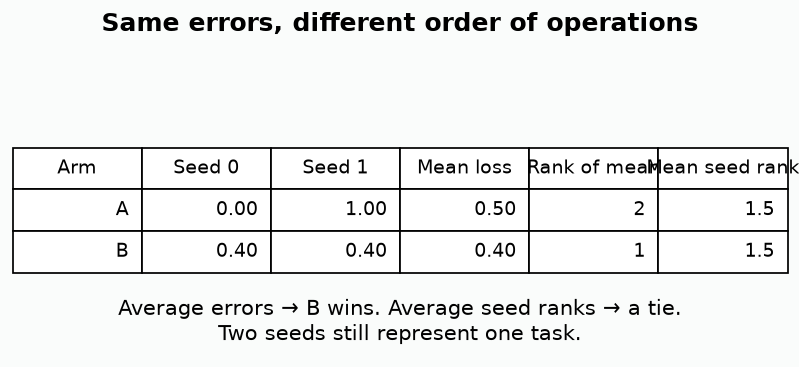

Synthetic two-seed fixture: rank the mean losses, not the individual-seed ranks. The interactive slider in the lesson keeps this baseline visible. [Open full-size figure](figures/l060/aggregation-v2.png).

Write `e_ds(m)` for error on dataset `d`, seed `s`, method `m`. First estimate `ē_d(m)=Σ_s e_ds(m)/S` with `S=3`. Within each dataset, assign rank 1 to the smallest mean error and average occupied positions on exact ties. Then average the `N` dataset ranks. The roster is supplied explicitly to `aggregate_panel`; inferring it only from successful records would fail to notice a completely absent dataset or model. Random and temporal panels are summarized separately.

The **Friedman null** is no systematic method effect in the dataset blocks. For `K` methods, rank dispersion is summarized by `Q=12N/[K(K+1)] × Σ_m [mean_rank(m)−(K+1)/2]²` without ties; SciPy applies a tie correction. Its chi-square reference has `K−1` degrees of freedom and is an approximation. Eleven tasks and five methods are a small panel; three temporal tasks are especially unsuitable for treating asymptotic p-values as precise. We label them exploratory and also compute a within-task method-label permutation calibration: 20,000 draws for the random panel and all 14,400 permutations after fixing the first of three temporal rows. This calibration assumes exchangeable method labels within independent task blocks under the null. It does not make a convenience sample representative.

A **Nemenyi critical difference** compares two mean ranks after accounting for the whole declared method pool. We compute `CD=q(.95,K,∞) × sqrt(K(K+1)/(12N))`, where `q` is SciPy's studentized-range quantile. The `1/sqrt(2)` convention is already absorbed in this form. Its threshold is exploratory here, particularly with three tasks, and is not a confidence interval on an error score. Consult [Demšar §3.2](https://jmlr.org/papers/v7/demsar06a.html) for the comparison framework and small-sample caution. No rejection does not establish equivalence.

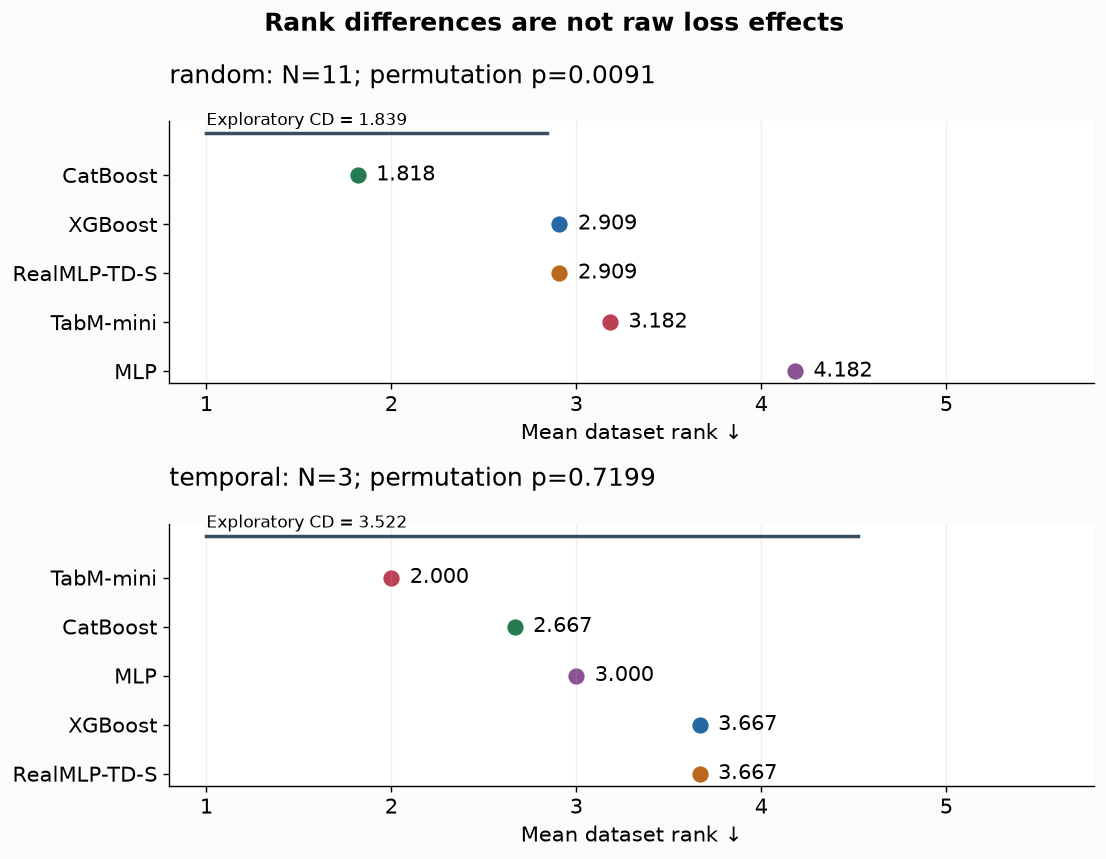

Fresh v2 dataset-level mean ranks and exploratory Nemenyi critical differences. Random and temporal panels have different task rosters; compare regimes on paired tasks. [Open full-size figure](figures/l060/ranks-v2.png).

### Pair first, then quantify variation

Within one dataset, compute `δ_s=e_ds(A)−e_ds(B)` using matching seed keys. Its mean is the measured error gap; a negative value favors A. The sample SD is `sqrt(Σ_s(δ_s−mean δ)²/(S−1))`; an approximate conditional 95% t interval is `mean δ ± t(.975,S−1) × SD/sqrt(S)`. With three seeds the multiplier is about 4.303. Pairing retains covariance: `Var(A−B)=Var(A)+Var(B)−2Cov(A,B)`. Subtracting unrelated means and adding their separate SDs ignores this structure.

These intervals describe only seed variation conditional on fixed rows, recipes and split. They are not calibrated coverage guarantees for a new enterprise, another temporal window or the general population of tabular datasets. Deterministic seeds can even give SD zero for an arm with little stochastic variation; that does not make its generalization error known exactly. Intervals are unadjusted across the many inspected task/model contrasts.

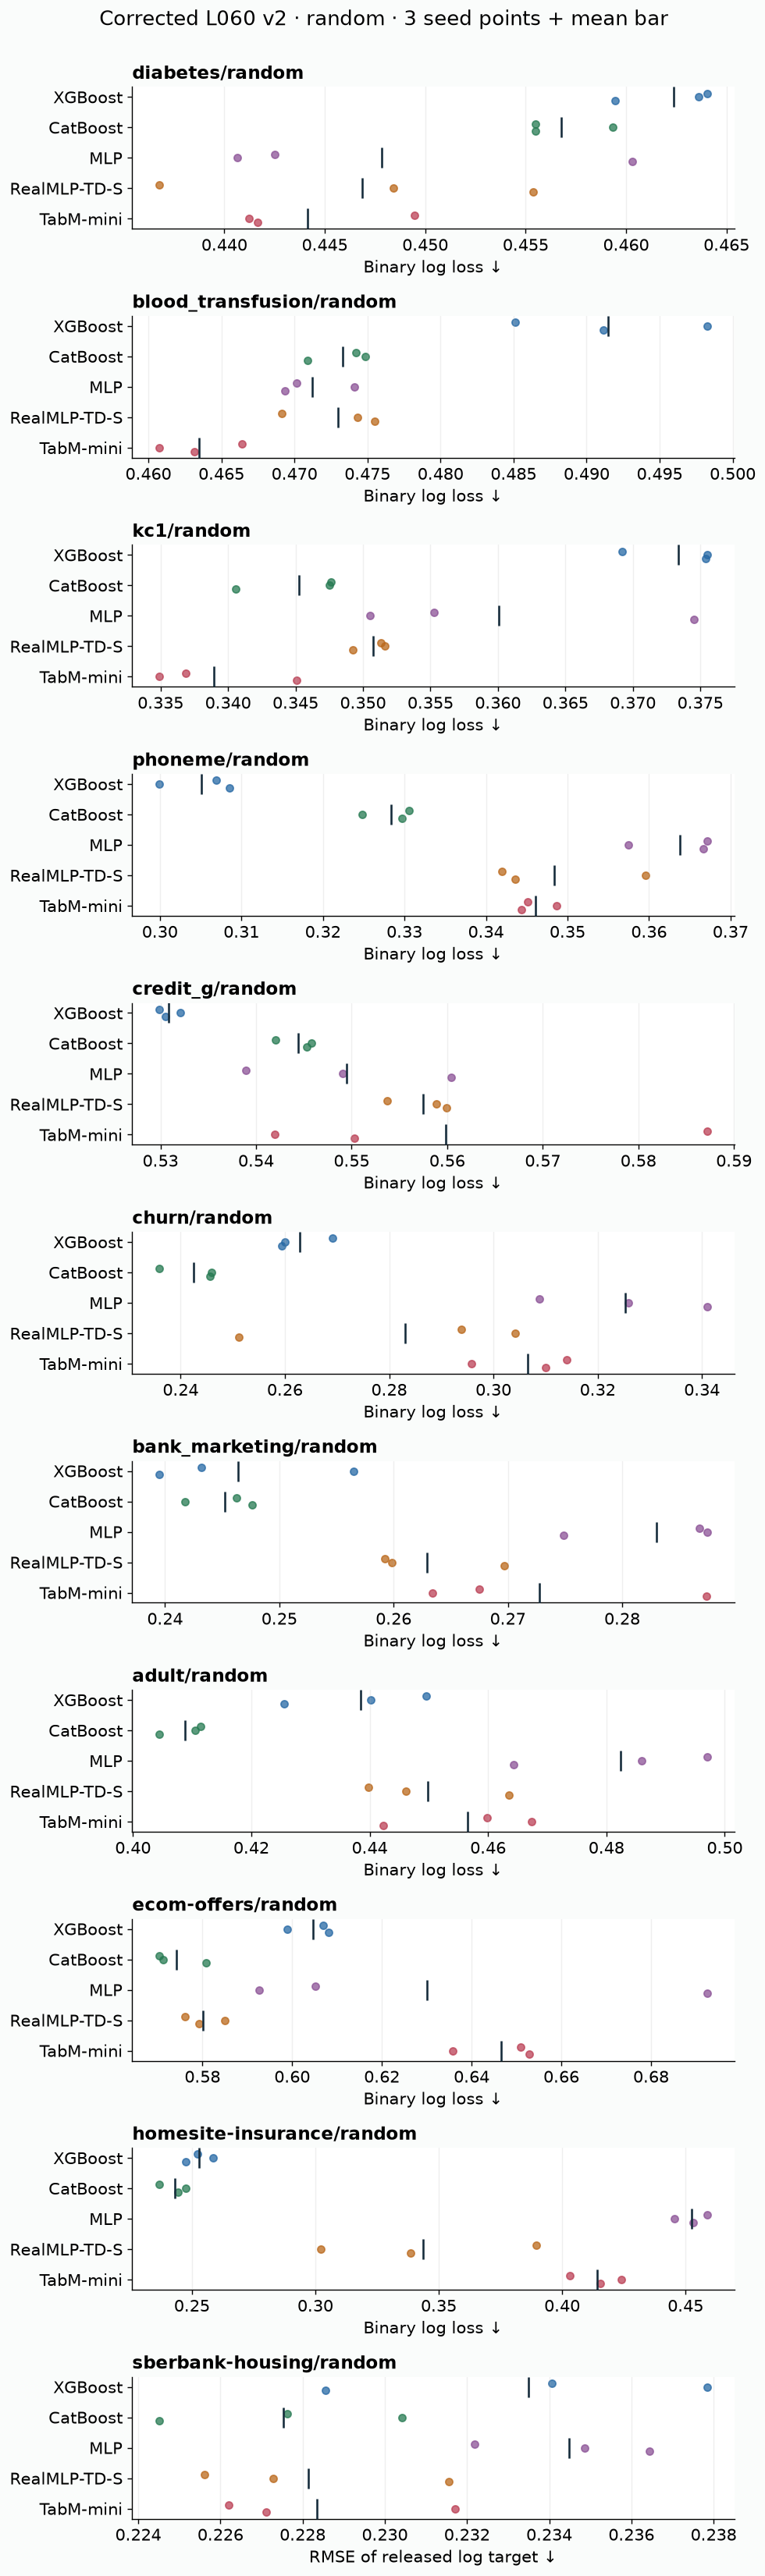

Fresh v2 random panel. All three seed points and the mean are shown per task; axes retain each task’s raw error units. No paper result reproduction. [Open full-size figure](figures/l060/scores-random-v2.png).

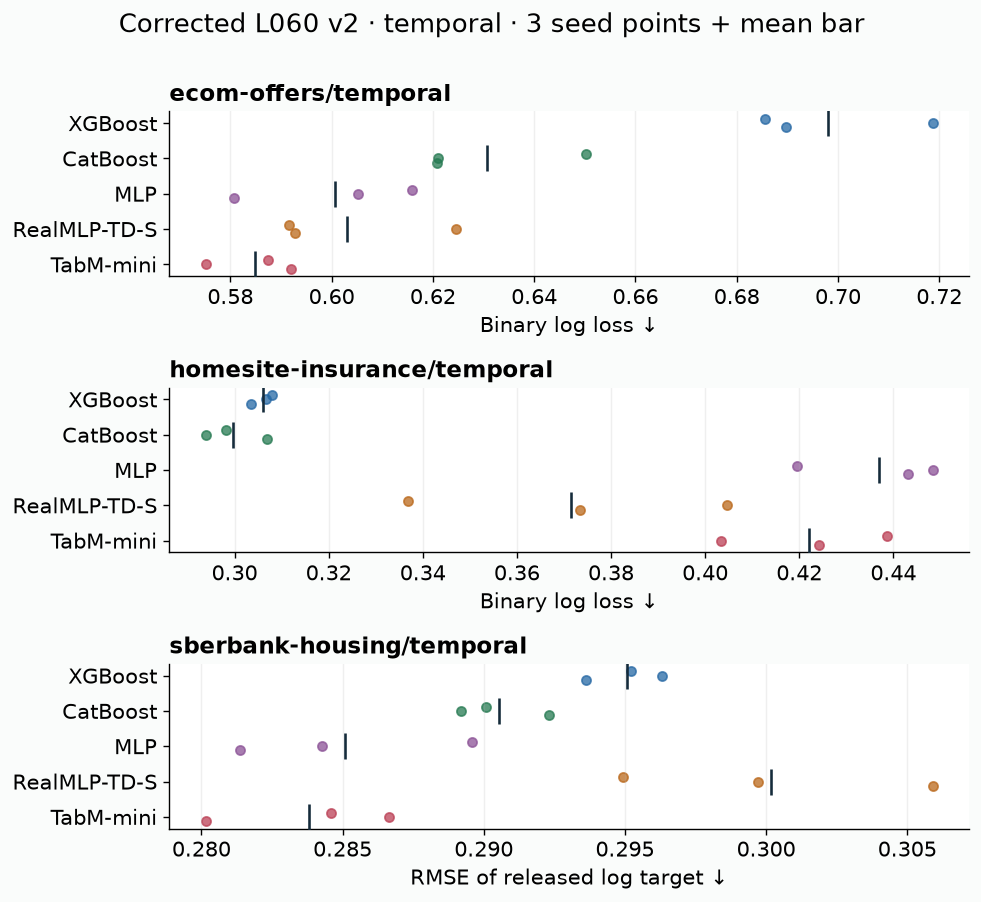

Fresh v2 temporal panel, with three seed points per arm. Sberbank uses RMSE of the released log(price_doc/full_sq) target. See the notebook for paired t intervals and all 70 task/arm summaries. [Open full-size figure](figures/l060/scores-temporal-v2.png).

### A measured reversal, with its uncertainty

The corrected Ecom Offers comparison makes the difference between a rank and a defensible decision concrete. Here every gap is **TabM-mini minus XGBoost**, so negative favors TabM; the intervals use three paired seeds on the fixed split.

| Task/regime | Mean raw loss gap | Conditional t95 | Interpretation |
|---|---:|---|---|
| Ecom Offers / random | +0.04180 | [0.03109, 0.05250] | TabM has larger log loss |
| Ecom Offers / temporal | −0.11314 | [−0.17868, −0.04760] | TabM has smaller log loss |
| Homesite / temporal | +0.11602 | [0.07275, 0.15929] | The Ecom preference does not transfer |

The Ecom relative gap changes by `−0.11314 − (+0.04180) = −0.15494`. This is a paired-task regime contrast, not a claim that every neural method becomes more robust in the future. A three-seed interval excluding zero concerns this fixed recipe/window only. The evidence does not isolate whether class balance, temporal changes, feature behavior or other differences drove the reversal. Inspect the saved per-row probabilities and class proportions before proposing a new experiment. The [analysis artifact](_analysis_l060_v2_results.json) contains all 56 non-baseline paired contrasts and their seed differences.

The results above are author-reference measurements, independent of the notebook's unexecuted student cells. The notebook reconstructs every score from the saved predictions and displays full seed points, conditional intervals, candidate choices and costs. Raw values remain available next to the ranked view so a rank difference cannot conceal a negligible practical gap.

## Quality and cost determine a conditional decision

A search-time comparison must include losing configurations. Our `fit_selection_seconds` spans all candidate fits and validation evaluations; `predict_seconds` spans the selected predictor on the complete test matrix. Common data loading and common median/one-hot preprocessing are outside those timers. Neural standardization/robust scaling is inside the fitter. The author run experienced variable host contention, so these timings are descriptive records and cannot establish hardware efficiency superiority. This is one-thread CPU evidence, not a cold end-to-end request latency benchmark and not GPU throughput. The historical `last_invocation_seconds` was only a resumed tail, so it must never be presented as total historical suite cost.

For a deployment decision, specify a task, an acceptable loss difference and a cost limit before examining a new test set. A procedure is **Pareto dominated** if another is no worse on both declared objectives and strictly better on at least one. A nondominated procedure merely remains eligible; it need not be preferred. A score-first ranking answers a different question from minimizing loss subject to a 10 ms prediction budget.

Compare the random-versus-temporal **paired model gap**, not only the two winners. If A−B is −.02 on shuffled rows and +.10 on later rows, the gap changes by .12. This suggests differential sensitivity to the regime. It does not identify temporal drift as the sole cause: windows can differ in difficulty, class balance, feature distributions and legal information. A follow-up should specify which factor is held fixed. The three released tasks are paired across regimes, so comparing the aggregate 11-task random rank to the aggregate three-task temporal rank confounds regime with task composition.

## Exit: write a report a skeptic can rerun

Complete the five code tasks, run the independent CHECK cells, reconstruct all 210 v2 metrics, and run the small fresh five-arm experiment through your live functions. Save `data/cache/l060-student/exit.json` with the source text of the live operations, evidence hashes, complete declared panel, reconstructed summaries, paired effects, permutation calibration, call counts and the seven-decision ledger. Write at least 120 words explaining one task's practical gap, one regime contrast, the timing definition and an evaluation that could reverse your recommendation. Code checks verify the artifact chain; the teacher must still assess your reasoning.

Then take the explicit **NEXT STEP** after EXIT: run the corrected `lab` panel again from a fresh output path, or the larger `closer` operator with 4,000 public rows, 128 neural epochs and 800 tree iterations. The notebook gate is off by default; a CPU Modal wrapper exists for unattended runs. Neither is a paper-reproduction preset. Full TabArena reproduction instead requires its curated suite, versioned wrapper, nested folds, candidate search and ensemble treatment; full TabReD replication requires the original task release, full feature treatment, three split pairs, model roster, metric and evaluation seeds. The [contract](l060-reproduction.md) separates these paths.

Connect this checkpoint to what comes next. Lesson 061 asks how a learned prior can replace per-task fitting; later pretrained predictors must still pass the same label-access, version and cost accounting. A future relational model adds an entity graph and point-in-time features, increasing the importance of these boundaries. The single-table baseline is the measured procedure it must beat, not an under-specified model name. Explain the boundary in your own words and ask the teacher about any operation you cannot trace.

## Start the live implementation
The five TODO functions must remain in this kernel's namespace. The provided driver below calls them directly. We first isolate their behavior on small fixtures, then test them on real saved predictions, then fit fresh models. Source text in this notebook identifies your code; saved author file hashes identify the separate reference operator.

In [ ]:
# PROVIDED — setup and CPU limits
import sys,copy,hashlib,json,time,math,itertools,inspect,functools,importlib.metadata
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from scipy.stats import rankdata,friedmanchisquare,studentized_range,t
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from threadpoolctl import threadpool_limits
from xgboost import XGBClassifier,XGBRegressor
from catboost import CatBoostClassifier,CatBoostRegressor
from IPython.display import display
for p in [Path.cwd(),Path.cwd()/'labs',Path.cwd().parent]:
    if (p/'relkit').is_dir():ROOT=p.resolve();sys.path.insert(0,str(ROOT));break
else:raise RuntimeError('Run the course bootstrap or start inside labs')
from relkit.data import load_tier_a,CACHE,SPECS
__file__=str(ROOT/'relkit/checkpoint_l060_v2.py')
torch.set_num_threads(1)
output=ROOT/'data/cache/l060-student';output.mkdir(parents=True,exist_ok=True)
print({name:importlib.metadata.version(name) for name in ['numpy','scipy','torch','scikit-learn','xgboost','catboost']})

## PROVIDED · Freeze the comparison ledger before reading results
This concrete ledger defines the author experiment you are about to audit. If a Lesson 059 EXIT exists locally, the cell prints its decisions so you can record discrepancies. Its absence does not block the checkpoint. The new smoke intentionally uses its separately declared reduced budget. Your final report must retain this ledger identity and label any post-result adjustment as a future hypothesis.

In [ ]:
# PROVIDED — a concrete prior decision record, before fitting
frozen_ledger={'metric':'binary log loss; RMSE of released log target','candidate_procedures':'five numeric/one-hot arms; corrected TabM-mini','split_identity':'public60/61; TabReD split0; IDs in author artifact','tuning_budget':'two candidates,24 epochs,100 trees,seeds0/1/2','selection_rule':'first minimum candidate; last minimum epoch','freeze_point':'before selected predictor sees test rows','postponed_adjustment':'native categorical route and new windows require fresh evaluation'}
frozen_ledger_sha256=hashlib.sha256(json.dumps(frozen_ledger,sort_keys=True).encode()).hexdigest()
prior_path=ROOT/'data/cache/l059-student/exit.json'
prior_ledger=json.loads(prior_path.read_text()).get('ledger') if prior_path.exists() else None
print('L059 ledger:',prior_ledger if prior_ledger else 'Not present in this runtime; use your saved seven decisions')
print('Frozen L060 declaration:',frozen_ledger)
print('Declaration identity:',frozen_ledger_sha256)

## TODO 1 · Validate the row boundary

**Goal:** Accept exactly train, val and test, each a nonempty one-dimensional integer ID array; reject duplicates within and across parts. Return True.

**Why:** No later statistic can repair an overlapped or misaligned evaluation.

**Hint boundary:** Inspect shape before concatenating; uniqueness must hold for the combined IDs.

In [ ]:
# TODO — validate_partitions
def validate_partitions(ids):
    raise NotImplementedError("Implement the live comparison operation")

In [ ]:
# CHECK — malformed structure and overlap cannot pass
assert validate_partitions({'train':[0,1],'val':[2],'test':[3]}) is True
for bad in [{'train':[0,0],'val':[2],'test':[3]}, {'train':[0],'val':[0],'test':[3]}, {'train':[[0]],'val':[2],'test':[3]}, {'train':[],'val':[2],'test':[3]}]:
    try: validate_partitions(bad)
    except ValueError: pass
    else: raise AssertionError('Reject duplicate, overlapping, non-vector or empty IDs')

## TODO 2 · Freeze a candidate

**Goal:** Return the first index of the smallest finite loss in a nonempty one-dimensional sequence.

**Why:** The selector receives validation losses only; deterministic ties make replay inspectable.

**Hint boundary:** Check all values before selecting an index.

In [ ]:
# TODO — choose_validation
def choose_validation(errors):
    raise NotImplementedError("Implement the live comparison operation")

In [ ]:
# CHECK — stable ties, no invalid candidate
assert choose_validation([.4,.2,.2]) == 1
for bad in [[],[.1,float('nan')],[[.2,.1]]]:
    try: choose_validation(bad)
    except ValueError: pass
    else: raise AssertionError('Reject empty, nonfinite or non-vector validation errors')

## TODO 3 · Reconstruct an honest metric

**Goal:** Require aligned finite nonempty vectors and a Boolean task flag. For regression compute RMSE. Otherwise validate labels in {0,1}, probabilities in [0,1], clip with float64 machine epsilon, and compute binary log loss.

**Why:** Wrong class convention or target units can produce plausible-looking scores.

**Hint boundary:** Validate before clipping. Work out the probability assigned to each observed label.

In [ ]:
# TODO — score_predictions
def score_predictions(y,p,regression):
    raise NotImplementedError("Implement the live comparison operation")

In [ ]:
# CHECK — explicit probability convention and target units
np.testing.assert_allclose(score_predictions([1,0],[.8,.3],False),(-np.log(.8)-np.log(.7))/2)
np.testing.assert_allclose(score_predictions([1,5],[4,1],True),np.sqrt(12.5))
for y,p,reg in [([0,1],[.2],False),([0,2],[.2,.8],False),([0,1],[.2,1.1],False),([0,1],[[.2],[.8]],False),([],[],True)]:
    try: score_predictions(y,p,reg)
    except ValueError: pass
    else: raise AssertionError('Reject misalignment, invalid labels/probabilities and empty data')

## TODO 4 · Check the declared panel and rank its seed means

**Goal:** Reject duplicate, missing or extra dataset/arm/seed keys against the explicit roster. Average errors over seeds first, then use average-tie rankdata. Return datasets, seeds, arms, details, mean_ranks, dataset_ranks, friedman_p, nemenyi_cd and uncertainty. Each detail includes dataset, arm, mean, sd, seed_values, conditional_t95 and seconds. SD and interval are None for one seed.

**Why:** A completely missing dataset disappears if the expected roster is inferred from successes. The experiment calls this function on both the full panel and one-seed smoke.

**Hint boundary:** A MultiIndex product expresses expected coverage. See the formulas above for the interval and critical difference; scipy.stats supplies the distribution quantiles.

In [ ]:
# TODO — aggregate_panel
def aggregate_panel(records,datasets,arms,seeds):
    raise NotImplementedError("Implement the live comparison operation")

In [ ]:
# CHECK — mean seeds THEN rank; explicit roster detects wholly missing tasks
fixture=[dict(dataset=d,arm=a,seed=s,error=e,seconds=1.) for d,rows in [('d1',[[0.,1.],[.4,.4],[.7,.7]]),('d2',[[.2,.2],[.3,.3],[.4,.4]]),('d3',[[.9,.9],[.1,.1],[.5,.5]])] for a,errors in zip(['A','B','C'],rows) for s,e in enumerate(errors)]
a=aggregate_panel(fixture,['d1','d2','d3'],['A','B','C'],[0,1])
np.testing.assert_allclose(a['mean_ranks']['A'],2.)
np.testing.assert_allclose(a['mean_ranks']['B'],4/3)
for bad in [fixture[:-1],fixture+[fixture[0]], [r for r in fixture if r['dataset']!='d3']]:
    try: aggregate_panel(bad,['d1','d2','d3'],['A','B','C'],[0,1])
    except ValueError: pass
    else: raise AssertionError('Reject missing cells, duplicates and entirely absent declared datasets')

## TODO 5 · Retain paired seed differences

**Goal:** For one task and two distinct arms, require matching unique seed sets with at least two pairs. Return n, mean, sd, t95, differences and direction for arm minus baseline, sorted by seed.

**Why:** Separate unpaired intervals discard covariance and can give the wrong impression of the gap.

**Hint boundary:** Join by seed, subtract first, then compute ddof=1 spread and the t interval.

In [ ]:
# TODO — paired_effect
def paired_effect(records,dataset,arm,baseline):
    raise NotImplementedError("Implement the live comparison operation")

In [ ]:
# CHECK — pair by seed, not incoming row order; subtract before computing spread
fixture=[dict(dataset='d',arm=a,seed=s,error=e) for a,values in [('A',[.1,.4,.7]),('B',[.2,.3,.6])] for s,e in enumerate(values)]
r=paired_effect(list(reversed(fixture)),'d','A','B')
np.testing.assert_allclose(r['mean'],1/30)
np.testing.assert_allclose(r['sd'],np.std([-.1,.1,.1],ddof=1))
assert r['n']==3 and r['t95'][0] < r['mean'] < r['t95'][1]
try: paired_effect(fixture[:-1],'d','A','B')
except ValueError: pass
else: raise AssertionError('Do not pair unequal seed sets or truncate them')

## PROVIDED · Validate every link in the author artifact
The following auditor is separate from fitting. It checks each row ID, shared target sequence, candidate choice and reconstructed metric, then calls your explicit-roster aggregator. A hash can identify an artifact; it cannot substitute for these semantic checks. Read why the target sequence must agree across both arms and seeds.

In [ ]:
# PROVIDED — artifact integrity
def audit_records(result):
    """Reconstruct predictions and test identity before presenting any result."""
    for audit in result['datasets'].values():validate_partitions(audit['ids'])
    target_by_dataset={}
    for r in result['records']:
        a=result['datasets'][r['dataset']]
        if r['test_ids']!=a['ids']['test']:raise ValueError('Prediction row order differs from declared test IDs')
        if r['dataset'] in target_by_dataset and target_by_dataset[r['dataset']]!=r['targets']:
            raise ValueError('Different targets across supposedly paired arms or seeds')
        target_by_dataset[r['dataset']]=r['targets']
        if len(r['targets'])!=len(r['test_ids']):raise ValueError('Target/ID length mismatch')
        if r['selected']!=choose_validation(r['validation_errors']):raise ValueError('Choice differs from validation minimum')
        if not np.isclose(r['error'],score_predictions(r['targets'],r['predictions'],a['regression']),atol=1e-12,rtol=1e-10):
            raise ValueError('Saved metric differs from predictions')
    summaries={}
    for regime,ds in result['design']['panels'].items():
        rows=[r for r in result['records'] if r['dataset'] in ds]
        summaries[regime]=aggregate_panel(rows,ds,result['design']['arms'],result['config']['seeds'])
    expected=set(sum(result['design']['panels'].values(),[]))
    if set(result['datasets'])!=expected or any(r['dataset'] not in expected for r in result['records']):
        raise ValueError('Undeclared or missing dataset')
    return summaries

In [ ]:
# PROVIDED — run the whole evidence audit through your functions
reference=json.loads((ROOT/'_verify_l060_v2_results.json').read_text())
assert reference['status']=='COMPLETE', 'An incomplete run cannot support this checkpoint'
summaries=audit_records(reference)
for regime,summary in summaries.items():
    print(regime,summary['datasets'],'dataset blocks')
    display(pd.DataFrame(summary['details'])[['dataset','arm','mean','sd','conditional_t95','seconds']])
    display(pd.Series(summary['mean_ranks'],name='Mean rank'))
    print('Exploratory asymptotic Friedman p:',summary['friedman_p'],'; exploratory CD:',summary['nemenyi_cd'])
paired=[dict(dataset=d,arm=a,**paired_effect(reference['records'],d,a,'XGBoost')) for d in reference['datasets'] for a in reference['design']['arms'] if a!='XGBoost']
display(pd.DataFrame(paired)[['dataset','arm','mean','sd','t95']])
cost=pd.DataFrame(reference['records']).groupby('arm')[['fit_selection_seconds','predict_seconds']].sum()
display(cost)
print('Costs exclude common loading/encoding and are confounded by variable host load; no hardware-normalized speed claim.')

### CHECK · Evidence mutation and roster omission
Predict what happens if a saved target changes after the validation choice. Selection must remain identical, while the reported error can no longer match the original prediction artifact. Then remove a whole dataset; an explicit expected roster must reject that too. These probes check the saved evidence boundary, not a proof of semantic feature legality.

In [ ]:
# CHECK — no test-driven choice; tampering must be detected
bad=copy.deepcopy(reference);bad['records'][0]['targets'][0]=1-bad['records'][0]['targets'][0]
assert choose_validation(bad['records'][0]['validation_errors'])==reference['records'][0]['selected']
for corrupted in [bad,dict(reference,records=[r for r in reference['records'] if r['dataset']!=next(iter(reference['datasets']))])]:
    try:audit_records(corrupted)
    except ValueError:pass
    else:raise AssertionError('Audit accepted changed targets or a missing declared task')
print('Target mutation and whole-task omission rejected')

## PROVIDED · Calibrate rank dispersion without a large-sample fiction
The exact temporal enumeration fixes the first task's labels because simultaneously renaming every method leaves the statistic unchanged. Enumerate all permutations in each remaining task: 120²=14,400 equally weighted arrangements for five methods. The larger panel uses 20,000 Monte Carlo arrangements with a plus-one correction. This tests exchangeability in the declared blocks, not representativeness of their sampling.

In [ ]:
# PROVIDED — conditional permutation calibration
def rank_permutation(ranks,draws=20000,seed=60):
    r=np.asarray(ranks,float)
    if r.ndim!=2 or not r.size or not np.isfinite(r).all():raise ValueError('Finite dataset by method ranks required')
    n,k=r.shape
    # Equivalent to Friedman ordering for fixed within-row tie patterns.
    center=(k+1)/2
    observed=float(np.sum((r.mean(0)-center)**2))
    exceed=0;total=0
    if n==3 and k<=5:
        # Global relabeling fixes the first row without changing dispersion.
        permutations=list(itertools.permutations(range(k)))
        for p in permutations:
            for q in permutations:
                score=np.sum(((r[0]+r[1,list(p)]+r[2,list(q)])/3-center)**2)
                exceed+=int(score>=observed-1e-12);total+=1
        p=exceed/total;mode='exact conditional method-label permutation; first row fixed'
        mc_se=None
    else:
        rng=np.random.default_rng(seed)
        for _ in range(draws):
            score=np.sum((np.stack([rng.permutation(row) for row in r]).mean(0)-center)**2)
            exceed+=int(score>=observed-1e-12)
        total=draws;p=(1+exceed)/(1+draws);mc_se=float(np.sqrt(p*(1-p)/(draws+1)))
        mode='Monte Carlo conditional method-label permutation, plus-one correction'
    return dict(p=float(p),mc_se=mc_se,draws=total,exceed=exceed,statistic=observed,seed=seed,mode=mode,
                assumption='Within each independent task block, method labels are exchangeable under the null; the convenience panel is not a random sample of enterprises')

In [ ]:
# PROVIDED — your seed-first ranks determine the calibrated test
permutation={reg:rank_permutation(list(s['dataset_ranks'].values())) for reg,s in summaries.items()}
display(pd.DataFrame(permutation).T)
assert permutation['temporal']['draws']==14400
# Degenerate tie fixture has no dispersion to reject.
assert rank_permutation(np.full((3,3),2.))['p']==1.

## PROVIDED · Reused model mechanics, visible from input to prediction
The following chunks are copied from the corrected canonical teaching models. These are provided because this lesson tests evaluation rather than redoing the architecture exercises. Trace the dimensions and objective anyway: a wrong reusable model invalidates an otherwise clean comparison. The model names in the fresh driver below resolve to these local definitions.

### PROVIDED · Input diversity, member loss and probability averaging

In [ ]:
# PROVIDED — Input diversity, member loss and probability averaging

def kaiming_(t):
    """Linear-style U(-1/sqrt(d_in), +1/sqrt(d_in)) for [...,d_in,d_out].

    PyTorch's kaiming helper assumes [d_out,d_in] and is wrong for this layout.
    Explicit fan-in also handles the independent [k,d_in,d_out] heads.
    """
    bound = 1 / math.sqrt(t.shape[-2])
    return nn.init.uniform_(t, -bound, bound)

def sign_pm1(k, d, generator=None):
    """Random ±1 initialisation for the first adapter (paper §3.2: diversity)."""
    return torch.where(torch.rand(k, d, generator=generator) < .5, -1., 1.)

def batchensemble_linear(x, weight, R, S, bias):
    """BatchEnsemble layer over k members (paper §3.2).

    x: [B, k, d_in]; weight (shared W): [d_in, d_out]; R: [k, d_in] or None;
    S: [k, d_out] or None; bias (B): [k, d_out]. Returns [B, k, d_out] computed as
    ((x ⊙ R) W) ⊙ S + B, with R/S skipped when None (the mini variant).
    """
    if R is not None:
        x = x * R
    h = torch.einsum('bki,io->bko', x, weight)
    if S is not None:
        h = h * S
    return h + bias

def packed_head(h, weight, bias):
    """k independent output heads. h: [B,k,d]; weight: [k,d,d_y]; bias: [k,d_y]."""
    return torch.einsum('bkd,kdo->bko', h, weight) + bias

def member_mean_loss(out, y, regression):
    """Mean over the k members of each member's loss (paper §5.1). out: [B,k,d_y]."""
    k = out.shape[1]
    if regression:
        return ((out[:, :, 0] - y.unsqueeze(1)) ** 2).mean()
    logp = out.log_softmax(-1)
    nll = -logp.gather(-1, y.view(-1, 1, 1).expand(-1, k, 1)).squeeze(-1)
    return nll.mean()

def ensemble_predict(out, regression):
    """Mean prediction over members: raw for regression, probabilities otherwise."""
    if regression:
        return out.mean(1)[:, 0]
    return out.softmax(-1).mean(1)

### PROVIDED · Shared mini backbone and distinct heads

In [ ]:
# PROVIDED — Shared mini backbone and distinct heads

class MLP(nn.Module):
    """Plain MLP baseline: N blocks of Linear→ReLU→Dropout, then a linear head.

    This is both the k=1 reference and the member architecture of the deep
    ensemble MLP^{×k}. Definition follows paper §3.3.
    """
    def __init__(self, din, width=64, depth=3, dropout=.1, regression=False, k=1):
        super().__init__()  # k is accepted and ignored so MLP and TabM share a signature
        dims = [din] + [width] * depth
        self.blocks = nn.ModuleList(nn.Linear(a, b) for a, b in zip(dims[:-1], dims[1:]))
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(width, 1 if regression else 2)
        self.regression = regression

    def forward(self, x):
        h = x
        for block in self.blocks:
            h = self.dropout(torch.relu(block(h)))
        return self.head(h)

class BatchEnsembleLinear(nn.Module):
    """One shared W with per-member multiplicative (R,S) and additive (B) adapters.

    ``first`` selects the diversity-creating adapter that is initialised with
    random ±1; all other adapters are initialised so they have no effect at the
    start (later R=S=1, identical random bias rows), matching the ``TabM`` initialisation in paper §3.3.
    ``shared_rs`` (mini) keeps only the first R, with ordinary shared biases.
    There is no S even in the first mini layer; all later R/S are absent.
    """
    def __init__(self, din, dout, k, first=False, shared_rs=False, generator=None):
        super().__init__()
        self.k = k
        self.weight = nn.Parameter(kaiming_(torch.empty(din, dout)))
        # Full TabM starts each member bias with the same nn.Linear-style draw.
        base_bias = torch.empty(dout).uniform_(-1 / math.sqrt(din), 1 / math.sqrt(din))
        self.bias = nn.Parameter(base_bias if shared_rs else base_bias.repeat(k, 1))
        self.R = nn.Parameter(sign_pm1(k, din, generator) if first else torch.ones(k, din)) \
            if first or not shared_rs else None
        self.S = None if shared_rs else nn.Parameter(torch.ones(k, dout))

    def forward(self, x):                                          # x: [B, k, din]
        return batchensemble_linear(x, self.weight, self.R, self.S, self.bias)

class PackedHead(nn.Module):
    """k independent output heads (one per submodel); d_y is tiny so this is cheap."""
    def __init__(self, width, dy, k):
        super().__init__()
        self.weight = nn.Parameter(kaiming_(torch.empty(k, width, dy)))
        self.bias = nn.Parameter(torch.empty(k, dy).uniform_(-1 / math.sqrt(width), 1 / math.sqrt(width)))

    def forward(self, h):                                          # h: [B, k, width]
        return packed_head(h, self.weight, self.bias)

class TabM(nn.Module):
    """One model imitating an ensemble of k MLPs (paper §3.3).

    forward returns per-member outputs of shape [B, k, d_y]. Use
    :meth:`predict` for the mean (ensemble) prediction and :meth:`member_losses`
    for the mean-over-members training objective.
    """
    def __init__(self, din, k=32, width=64, depth=3, dropout=.1,
                 regression=False, arch='mini', seed=0):
        super().__init__()
        assert arch in ('mini', 'tabm')
        g = torch.Generator().manual_seed(seed)
        self.k, self.regression, self.arch = k, regression, arch
        dims = [din] + [width] * depth
        shared_rs = arch == 'mini'
        self.blocks = nn.ModuleList(
            BatchEnsembleLinear(a, b, k, first=(i == 0), shared_rs=shared_rs, generator=g)
            for i, (a, b) in enumerate(zip(dims[:-1], dims[1:])))
        self.dropout = nn.Dropout(dropout)
        self.head = PackedHead(width, 1 if regression else 2, k)

    def forward(self, x):
        # 3-D inputs permit independent per-member batches in the closer track.
        h = x.unsqueeze(1).expand(-1, self.k, -1) if x.ndim == 2 else x
        if h.ndim != 3 or h.shape[1] != self.k:
            raise ValueError('Expected [B,din] or [B,k,din]')
        for block in self.blocks:
            h = self.dropout(torch.relu(block(h)))
        return self.head(h)                                       # [B,k,d_y]

    def predict(self, x):
        """Ensemble prediction: mean over members (probabilities if classifying)."""
        return ensemble_predict(self(x), self.regression)

    def member_losses(self, x, y):
        """Mean over the k members of each member's supervised loss (paper §5.1)."""
        return member_mean_loss(self(x), y, self.regression)

    def member_predictions(self, x):
        """Per-member predictions [B,k,(d_y)] for individual-vs-collective analysis."""
        out = self(x)
        if self.regression:
            return out[:, :, 0]
        return out.softmax(-1)

### PROVIDED · Training-derived robust coordinates and scaled linear map

In [ ]:
# PROVIDED — Training-derived robust coordinates and scaled linear map

def robust_parameters(x):
    """Fit training-column medians and scales, including zero-IQR fallbacks."""
    median = np.median(x, axis=0)
    iqr = np.quantile(x, .75, axis=0) - np.quantile(x, .25, axis=0)
    span = np.ptp(x, axis=0)
    denominator = np.where(iqr != 0, iqr, span / 2)
    scale = np.divide(1., denominator, out=np.zeros_like(denominator), where=denominator != 0)
    return median, scale

def smooth_clip(z):
    """§3: monotone smooth saturation in (-3,3), without hard clipping."""
    return z / np.sqrt(1 + (z / 3) ** 2)

class RobustSmooth:
    def fit(self, x):
        x = np.asarray(x, dtype=np.float64)
        if x.ndim != 2 or not len(x) or not np.isfinite(x).all():
            raise ValueError('Fit requires a nonempty finite numeric matrix')
        self.median, self.scale = robust_parameters(x)
        return self

    def transform(self, x):
        return smooth_clip((np.asarray(x) - self.median) * self.scale).astype('float32')

def coslog4(t):
    """§3: four cycles over normalized optimizer-step progress 0 <= t <= 1."""
    return .5 * (1 - math.cos(2 * math.pi * math.log2(1 + 15 * t)))

def ntp_linear(x, weight, bias):
    """W is [input,output]; scale the matrix product, not the bias."""
    return (x @ weight) / math.sqrt(x.shape[-1]) + bias

### PROVIDED · RealMLP layers, feature scales and optimizer groups

In [ ]:
# PROVIDED — RealMLP layers, feature scales and optimizer groups

class NTPLinear(nn.Module):
    def __init__(self, din, dout, zero=False):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(din, dout) * (0 if zero else 1))
        self.bias = nn.Parameter(torch.randn(1, dout) * (0 if zero else 1))

    def forward(self, x):
        return ntp_linear(x, self.weight, self.bias)

class RealMLPS(nn.Module):
    """Three hidden layers, learned input scales; zero head; no dropout/decay."""
    def __init__(self, din, width=256, regression=False):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(din))
        dims = [din, width, width, width, 1 if regression else 2]
        self.layers = nn.ModuleList([NTPLinear(a,b,zero=i==3)
                                    for i,(a,b) in enumerate(zip(dims[:-1],dims[1:]))])
        self.activation = nn.Mish() if regression else nn.SELU()

    def forward(self, x):
        h = x * self.scale
        for layer in self.layers[:-1]:
            h = self.activation(layer(h))
        return self.layers[-1](h)

    def parameter_groups(self):
        return [dict(params=[self.scale], factor=6.),
                dict(params=[l.weight for l in self.layers], factor=1.),
                dict(params=[l.bias for l in self.layers], factor=.1)]

## PROVIDED · Fitting is separated from test evaluation
First inspect the train-only encoder and splitter. Then follow fit_candidate: tree candidates return after fixed rounds; neural candidates fit all epochs and restore the best validation state. Its signature contains no test data. The runner calls your selector, predicts, and scores in that order. `fit_selection_seconds` includes every candidate and its validation work.

In [ ]:
# PROVIDED — random_task
def random_task(name,cap=900,seed=60):
    # Keep provenance alongside values, with exact row identities before reset_index.
    if name=='breast_cancer':
        x,y=load_breast_cancer(return_X_y=True,as_frame=True)
        digest=hashlib.sha256(pd.util.hash_pandas_object(x,index=True).values.tobytes()+y.to_numpy().tobytes()).hexdigest()
        source='sklearn Wisconsin Diagnostic Breast Cancer'
    else:
        x,y=load_tier_a(name);source=f'OpenML {SPECS[name]["openml_id"]}'
        digest=hashlib.sha256((CACHE/f'{name}.parquet').read_bytes()).hexdigest()
    y=np.asarray(y,dtype='int64');ids=np.arange(len(y))
    if len(ids)>cap:ids=np.sort(np.random.default_rng(seed).choice(ids,cap,replace=False))
    train,test=train_test_split(ids,test_size=.2,random_state=seed,stratify=y[ids])
    train,val=train_test_split(train,test_size=.25,random_state=seed+1,stratify=y[train])
    parts=dict(train=train,val=val,test=test);validate_partitions(parts)
    audit=dict(source=source,data_sha256=digest,split_seed=seed,row_sampling_seed=seed,
               ids={s:v.tolist() for s,v in parts.items()},regression=False)
    return {s:x.iloc[ix].reset_index(drop=True) for s,ix in parts.items()},{s:y[ix] for s,ix in parts.items()},False,audit

In [ ]:
# PROVIDED — encode_train
def encode_train(raw):
    num=list(raw['train'].select_dtypes(include='number').columns)
    cat=[c for c in raw['train'] if c not in num]
    pieces=[]
    if num:pieces.append(('num',make_pipeline(SimpleImputer(strategy='median',keep_empty_features=True)),num))
    if cat:
        raw={s:v.copy() for s,v in raw.items()}
        for v in raw.values():v[cat]=v[cat].astype(str)
        pieces.append(('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),cat))
    prep=ColumnTransformer(pieces,sparse_threshold=0)
    train=prep.fit_transform(raw['train']).astype('float32')
    return dict(train=train,**{s:prep.transform(raw[s]).astype('float32') for s in ['val','test']})

In [ ]:
# PROVIDED — fit_candidate
def fit_candidate(arm,train,ytrain,val,yval,regression,seed,candidate,cfg):
    """Returns a frozen predictor, validation error and selected epoch; no test inputs."""
    if arm in ['XGBoost','CatBoost']:
        if arm=='XGBoost':
            cls=XGBRegressor if regression else XGBClassifier
            model=cls(n_estimators=cfg['trees'],max_depth=[3,6][candidate],learning_rate=.05,
                      n_jobs=1,random_state=seed,subsample=.8,colsample_bytree=.8,tree_method='hist')
        else:
            cls=CatBoostRegressor if regression else CatBoostClassifier
            model=cls(iterations=cfg['trees'],depth=[4,6][candidate],learning_rate=.05,
                      thread_count=1,random_seed=seed,verbose=False,allow_writing_files=False)
        model.fit(train,ytrain)
        pred=model.predict if regression else lambda x:model.predict_proba(x)[:,1]
        return pred,score_predictions(yval,pred(val),regression),None
    torch.manual_seed(seed)
    prep=RobustSmooth().fit(train) if arm=='RealMLP-TD-S' else StandardScaler().fit(train)
    tr=torch.tensor(prep.transform(train),dtype=torch.float32)
    va=torch.tensor(prep.transform(val),dtype=torch.float32)
    mu,sd=(float(ytrain.mean()),max(float(ytrain.std()),1e-8)) if regression else (0.,1.)
    yt=torch.tensor((ytrain-mu)/sd,dtype=torch.float32 if regression else torch.long)
    if arm=='RealMLP-TD-S':
        model=RealMLPS(tr.shape[1],width=64,regression=regression)
        opt=torch.optim.Adam(model.parameter_groups(),betas=(.9,.95),eps=1e-8,weight_decay=0.)
    else:
        cls=TabM if arm=='TabM-mini' else MLP
        extra=dict(k=8,arch='mini',seed=seed) if arm=='TabM-mini' else {}
        model=cls(din=tr.shape[1],width=64,depth=3,dropout=.1,regression=regression,**extra)
        opt=torch.optim.AdamW(model.parameters(),lr=[.001,.003][candidate],weight_decay=1e-4)
    def prediction(z):
        model.eval()
        with torch.no_grad():
            out=model.predict(z) if arm=='TabM-mini' else model(z)
            if arm!='TabM-mini':out=out[:,0] if regression else out.softmax(-1)
        p=out.numpy();return p*sd+mu if regression else p[:,1]
    best=float('inf');state=None;best_epoch=None;steps=max(1,int(np.ceil(len(tr)/128)))
    for epoch in range(cfg['epochs']):
        model.train()
        for batch,idx in enumerate(torch.randperm(len(tr)).split(128)):
            if arm=='RealMLP-TD-S':
                lr=(.07 if regression else .04)*[1.,.5][candidate]*coslog4((epoch*steps+batch)/(cfg['epochs']*steps))
                for group in opt.param_groups:group['lr']=lr*group['factor']
            if arm=='TabM-mini':loss=model.member_losses(tr[idx],yt[idx])
            else:
                out=model(tr[idx]);loss=nn.functional.mse_loss(out[:,0],yt[idx]) if regression else nn.functional.cross_entropy(out,yt[idx],label_smoothing=.1 if arm=="RealMLP-TD-S" else 0.)
            opt.zero_grad();loss.backward();opt.step()
        score=score_predictions(yval,prediction(va),regression)
        if score<=best:best=score;state=copy.deepcopy(model.state_dict());best_epoch=epoch+1
    model.load_state_dict(state)
    return lambda x:prediction(torch.tensor(prep.transform(x),dtype=torch.float32)),best,best_epoch

In [ ]:
# PROVIDED — declared budgets
PRESETS={'smoke': {'cap': 240, 'eval_cap': 60, 'epochs': 6, 'trees': 30, 'seeds': [0], 'candidates': 1}, 'lab': {'cap': 900, 'eval_cap': 180, 'epochs': 24, 'trees': 100, 'seeds': [0, 1, 2], 'candidates': 2}, 'closer': {'cap': 4000, 'eval_cap': 600, 'epochs': 128, 'trees': 800, 'seeds': [0, 1, 2], 'candidates': 2}}

In [ ]:
# PROVIDED — complete fresh fitting driver; no existing output is overwritten
def run_checkpoint(preset='lab',output=None):
    lesson=60
    torch.set_num_threads(1);cfg=PRESETS[preset].copy()
    names=['diabetes','blood_transfusion','kc1','phoneme','credit_g','churn','bank_marketing','adult']
    arms=['XGBoost','CatBoost','MLP','RealMLP-TD-S','TabM-mini']
    if preset=='smoke':names=names[:1]
    result=dict(lesson=lesson,preset=preset,config=cfg,records=[],datasets={},verdict='INCOMPARABLE',
        versions={p:importlib.metadata.version(p) for p in ['torch','numpy','scikit-learn','catboost','xgboost']},
        source_sha256=hashlib.sha256(Path(__file__).read_bytes()).hexdigest(),
        note='Numeric/one-hot inputs for all arms; fixed small recipes; no published benchmark reproduction')
    out=Path(output or ROOT/'_verify_l060_v2_results.json')
    # Deliberately no resume: preserve existing evidence and choose a fresh output.
    if out.exists():raise ValueError(f'{out}: already exists; choose a new output path')
    out.parent.mkdir(parents=True,exist_ok=True)
    result['operator_version']='l060-v2-corrected-tabm'
    dependencies=['checkpoint_l060_v2.py','comparison_l060.py','tabm_v2.py','realmlp.py','data.py','temporal_experiment.py']
    result['source_hashes']={f:hashlib.sha256((Path(__file__).parent/f).read_bytes()).hexdigest() for f in dependencies}
    tasks=[(name,'random') for name in names]
    if lesson==60 and preset!='smoke':
        tasks += [(name,split) for name in ['ecom-offers','homesite-insurance','sberbank-housing'] for split in ['random','temporal']]
    result['design']={'arms':arms,'panels':{reg:[name+'/'+regime for name,regime in tasks if regime==reg] for reg in ['random','temporal'] if any(regime==reg for _,regime in tasks)}}
    result['status']='IN_PROGRESS'
    start=time.perf_counter()
    with threadpool_limits(limits=1):
        for name,split in tasks:
            key=name+'/'+split
            if name in names:raw,y,reg,audit=random_task(name,cfg['cap'],60 if lesson==60 else 70)
            else:
                from relkit.temporal_experiment import load_release
                raw,y,reg,audit=load_release(name,split,train_cap=int(cfg['cap']*.6),eval_cap=cfg['eval_cap'],root=ROOT/'data/cache/l055')
                raw={s:pd.DataFrame(v) for s,v in raw.items()}
                folder=ROOT/'data/cache/l055'/name/name
                parts={}
                for i,part in enumerate(['train','val','test']):
                    pool=np.load(folder/'splits'/audit['split']/(part+'.npy'))
                    cap=int(cfg['cap']*.6) if part=='train' else cfg['eval_cap']
                    ids=np.sort(np.random.default_rng(550+i).choice(pool,min(cap,len(pool)),replace=False))
                    assert hashlib.sha256(ids.tobytes()).hexdigest()==audit['index_hashes'][part]
                    parts[part]=ids.tolist()
                audit['ids']=parts;audit['regression']=reg
                audit['target_units']='released log target (not currency)' if reg else 'binary 0/1'
                files=['info.json','y.npy','x_meta.npy','x_num.npy','x_bin.npy','x_cat.npy']
                audit['data_hashes']={f:hashlib.sha256((folder/f).read_bytes()).hexdigest() for f in files if (folder/f).exists()}
            validate_partitions(audit['ids'])
            if key in result['datasets'] and result['datasets'][key]!=audit:
                raise ValueError('Data or row partition changed while resuming: '+key)
            x=encode_train(raw);result['datasets'][key]=audit
            for seed in cfg['seeds']:
                for arm in arms:
                    if any(r['dataset']==key and r['seed']==seed and r['arm']==arm for r in result['records']):continue
                    begin=time.perf_counter();candidates=[]
                    for candidate in range(1 if arm.startswith(('TabPFN','TabICL')) else cfg['candidates']):
                        candidates.append(fit_candidate(arm,x['train'],y['train'],x['val'],y['val'],reg,seed,candidate,cfg))
                    selected=choose_validation([c[1] for c in candidates]);predict,valid,epoch=candidates[selected]
                    fit_seconds=time.perf_counter()-begin;tick=time.perf_counter();pred=predict(x['test']);predict_seconds=time.perf_counter()-tick
                    record=dict(dataset=key,arm=arm,seed=seed,error=score_predictions(y['test'],pred,reg),metric='RMSE' if reg else 'log_loss',
                        seconds=fit_seconds+predict_seconds,fit_selection_seconds=fit_seconds,predict_seconds=predict_seconds,
                        validation_errors=[c[1] for c in candidates],selected=selected,epoch=epoch,
                        predictions=pred.tolist(),targets=y['test'].tolist(),test_ids=audit['ids']['test'],
                        class_order=None if reg else [0,1],candidate_epochs=[c[2] for c in candidates],
                        cost_scope='sum of all candidate fitting and validation plus selected predict; common encoding/loading excluded')
                    result['records'].append(record);out.write_text(json.dumps(result,indent=2,allow_nan=False)+'\n')
                    print(key,seed,arm,round(record['error'],5),round(record['seconds'],2),flush=True)
    result['summary']=audit_records(result)
    result['status']='COMPLETE'
    result['last_invocation_seconds']=time.perf_counter()-start
    out.write_text(json.dumps(result,indent=2,allow_nan=False)+'\n')
    return result

In [ ]:
# PROVIDED — capture actual kernel code; repository hashes are reference identities
KERNEL_NAMES=['validate_partitions', 'choose_validation', 'score_predictions', 'aggregate_panel', 'paired_effect', 'audit_records', 'rank_permutation', 'random_task', 'encode_train', 'fit_candidate', 'run_checkpoint', 'kaiming_', 'sign_pm1', 'batchensemble_linear', 'packed_head', 'member_mean_loss', 'ensemble_predict', 'MLP', 'BatchEnsembleLinear', 'PackedHead', 'TabM', 'robust_parameters', 'smooth_clip', 'RobustSmooth', 'coslog4', 'ntp_linear', 'NTPLinear', 'RealMLPS']
def capture_kernel_identity():
    sources={}
    for name in KERNEL_NAMES:
        obj=inspect.unwrap(globals()[name])
        if inspect.isclass(obj):
            sources[name]={method:inspect.getsource(value) for method,value in vars(obj).items() if inspect.isfunction(value)}
        else:sources[name]=inspect.getsource(obj)
    content={'sources':sources,'presets':copy.deepcopy(PRESETS),'capture_source':inspect.getsource(capture_kernel_identity)}
    content['sha256']=hashlib.sha256(json.dumps(content,sort_keys=True).encode()).hexdigest()
    return content

def attach_kernel_identity(result,path):
    result['repository_source_hashes_are_reference_only']=True
    result['source_hashes_scope']='Repository reference files; actual live notebook functions and class methods are recorded separately'
    result['kernel_identity']=capture_kernel_identity()
    Path(path).write_text(json.dumps(result,indent=2,allow_nan=False)+'\n')
    return result

## Run a fresh five-arm smoke through your live functions
This small execution check uses only diabetes, one seed, one candidate and six epochs. It cannot establish a comparative winner. We count the calls to all five functions across a full saved-panel audit, paired-effects calculation and fresh fitting. The student functions are restored afterward. The run refuses to reuse an existing result filename; each invocation gets a new name.

In [ ]:
# PROVIDED — substantive live wiring check and fresh measurements
names=['validate_partitions','choose_validation','score_predictions','aggregate_panel','paired_effect']
originals={n:globals()[n] for n in names};calls={n:0 for n in names}
def counted(name,fn):
    @functools.wraps(fn)
    def wrapper(*args,**kwargs):calls[name]+=1;return fn(*args,**kwargs)
    return wrapper
for n,fn in originals.items():globals()[n]=counted(n,fn)
try:
    summaries=audit_records(reference)
    paired=[dict(dataset=d,arm=a,**paired_effect(reference['records'],d,a,'XGBoost')) for d in reference['datasets'] for a in reference['design']['arms'] if a!='XGBoost']
    fresh_path=output/f'smoke-{time.time_ns()}.json'
    with threadpool_limits(1):fresh=run_checkpoint('smoke',fresh_path)
    attach_kernel_identity(fresh,fresh_path)
finally:
    for n,fn in originals.items():globals()[n]=fn
assert all(v>0 for v in calls.values()), 'Every live function must reach actual analysis or fitting'
assert len(fresh['records'])==5 and fresh['status']=='COMPLETE'
print('Live call counts:',calls)
display(pd.DataFrame(fresh['records'])[['arm','error','selected','epoch']])

## EXIT TICKET · Write the claim you can defend
Save the declared protocol, reconstructed summaries, paired effects, calibrated tests, fresh smoke and live source text. Supply all seven ledger fields. If your Lesson 059 ledger differs, identify the difference and classify the new run correctly. In at least 120 words, discuss a concrete per-task gap, a paired random/temporal contrast, the cost definition, your preferred deployment baseline under a stated objective, and a fresh test that could reverse it. State that the paper results are INCOMPARABLE and why. Submit the artifact and completed notebook; written reasoning needs teacher review.

In [ ]:
# EXIT — your report and frozen decisions
verdict = ''
ledger = {'metric': '', 'candidate_procedures': '', 'split_identity': '', 'tuning_budget': '', 'selection_rule': '', 'freeze_point': '', 'postponed_adjustment': ''}

In [ ]:
# EXIT — persist concrete, inspectable work
assert len(verdict.split())>=120, 'Write the interpretation before submitting'
required={'metric','candidate_procedures','split_identity','tuning_budget','selection_rule','freeze_point','postponed_adjustment'}
assert set(ledger)==required and all(ledger.values()), 'Complete every frozen decision'
live_names=['validate_partitions', 'choose_validation', 'score_predictions', 'aggregate_panel', 'paired_effect', 'audit_records', 'rank_permutation', 'random_task', 'encode_train', 'fit_candidate', 'run_checkpoint', 'kaiming_', 'sign_pm1', 'batchensemble_linear', 'packed_head', 'member_mean_loss', 'ensemble_predict', 'MLP', 'BatchEnsembleLinear', 'PackedHead', 'TabM', 'robust_parameters', 'smooth_clip', 'RobustSmooth', 'coslog4', 'ntp_linear', 'NTPLinear', 'RealMLPS']
live_sources={}
for name in live_names:
    obj=globals()[name]
    if inspect.isclass(obj):
        live_sources[name]={method:inspect.getsource(value) for method,value in vars(obj).items() if inspect.isfunction(value)}
    else:live_sources[name]=inspect.getsource(obj)
artifact=dict(lesson=60,frozen_ledger=frozen_ledger,frozen_ledger_sha256=frozen_ledger_sha256,prior_ledger=prior_ledger,ledger=ledger,verdict=verdict,design=reference['design'],summaries=summaries,paired_effects=paired,permutation=permutation,fresh=fresh,calls=calls,live_sources=live_sources,
    live_sha256=hashlib.sha256(json.dumps(live_sources,sort_keys=True).encode()).hexdigest(),
    author_evidence_sha256=hashlib.sha256((ROOT/'_verify_l060_v2_results.json').read_bytes()).hexdigest(),
    paper_reproduction='INCOMPARABLE',timing_limit='Variable host load; common data loading and encoding excluded')
(output/'exit.json').write_text(json.dumps(artifact,indent=2,allow_nan=False))
print('Saved data/cache/l060-student/exit.json. Submit this and your completed notebook.')

## NEXT STEP · Refit the corrected panel at a declared budget
This is a runnable extension, with the same visible functions. `lab` repeats the 210-record panel; `closer` increases sample/epoch/tree budgets. Neither is TabArena's or TabReD's original protocol. The gate is off; full TabReD data may need downloading. Reruns choose fresh output names. For unattended CPU work use the separately supplied Modal wrapper described in the reproduction contract. No cloud run is implied by this notebook.

In [ ]:
# PROVIDED — explicit optional execution gate after the required EXIT
RUN_LARGER_LOCAL=False
REPRO_PRESET='closer'
if RUN_LARGER_LOCAL:
    from _fetch_l055 import fetch
    fetch()
    larger_path=output/f'{REPRO_PRESET}-{time.time_ns()}.json'
    with threadpool_limits(1):larger=run_checkpoint(REPRO_PRESET,larger_path)
    attach_kernel_identity(larger,larger_path)
    print('Verified here: corrected local panel. Paper claim: cited. Scale-up: INCOMPARABLE to original protocols.')
else:print('Scale-up NOT_RUN in this kernel. Full paper result reproduction remains INCOMPARABLE.')